Week 7 (11/04/2025) - Classification

In [ ]:
import seaborn as sns

iris = sns.load_dataset("iris")

# Plot the distribution of the flower species in the dataset.
sns.pairplot(iris, hue="species", height=2)

Generally speaking, a model should be able to find a trade-off between bias and variance.
If this trade-off is not achieved, then the model is not good as it is characterised by underfitting (the model is too simple) or by overfitting (the model performs well with the training set, but it fails to generalize the problem for new data).

If the labels are discrete/qualitative, it is possible to build a classificator for a dataset by using the Gaussian Naive Bayes algorithm, which tries to compute the probability that a given sample belongs to a certain class given the sample's feature.
Most particularly, the Gaussian approach is used because, generally speaking, it is assumed that the samples follow a Gaussian distribution.

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load the iris dataset.
iris = sns.load_dataset("iris")

# Start by taking the data of the dataset.
X_iris = iris.drop("species", axis=1) # remove the "Species" column

# Similarly, it is possible to extract the classification labels of a dataset.
y = iris["species"]

# After preparing the data, create an instance of the classification model.
model = GaussianNB() # it is also possible, but not necessary, to specify prior probabilities for the model

# Train the model by fitting with the training set.
model.fit(X_iris, y)

# Check whether the model works by making predictions on the data only.
y_prediction = model.predict(X_iris)

# It is possible to check the performance of the prediction by comparing the labels to the prediction labels.
accuracy = accuracy_score(y, y_prediction)
print(accuracy) # having a score of 0.96 means that the model has 96% accuracy

# However, there is a major issue in this model as the same data are used for training AND prediction.
# In a more general way, the new data should contain the same type of samples but it should provides samples that have never been seen by the model before.

0.96


Better version of the classificator that divides the data into two groups.
The first group, known as the "training set", will be used for training, whereas the second group, known as the "testing set", is used for testing.

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load the iris dataset and recover the data and the corresponding classification labels.
iris = sns.load_dataset("iris")
X_iris = iris.drop("species", axis=1) # data
y = iris["species"] # labels

# Start by creating the training and testing datasets from the iris dataset.
X_train, X_test, y_train, y_test = train_test_split(X_iris, y, train_size=0.5) # split the dataset so that 50% is used for the training set and the other 50% is used for the testing set
# N.B.: It is possible to specify a random state to determine whether the sets will always change or will always be the same according to a given seed.

# Create an instance of the classification model.
model = GaussianNB() # it is also possible, but not necessary, to specify prior probabilities for the model

# Train the model by fitting with the training set.
model.fit(X_train, y_train)

# Check whether the model works by making predictions on the testing set only.
y_prediction = model.predict(X_test)

# It is possible to check the performance of the prediction by comparing the labels to the prediction labels.
accuracy = accuracy_score(y_test, y_prediction)
print(accuracy)

0.9466666666666667


Whenever the labels are continuous (not discrete), it is possible to perform supervised learning by regression.

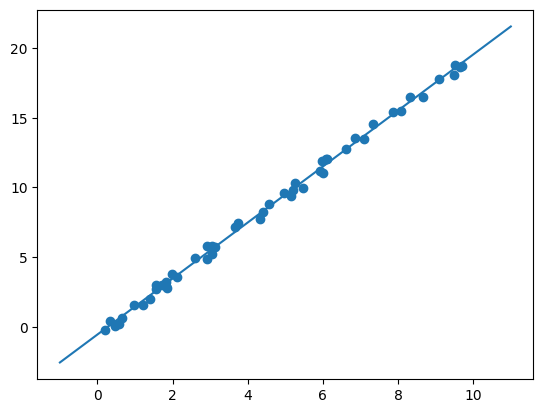

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Start by generating a random generator.
rng = np.random.RandomState(42) # fix a random seed for the regression model

# Create the coordinates for the data points: assume 50 points are used.
x = 10 * rng.random(50) # generate the points
y = 2 * x - 1 + rng.rand(50) # place the points over a line
# Visualize the training points.
# plt.scatter(x, y)
# plt.show()

# N.B.: Scikit-Learn wants to use points as 2D matrices for simplicity.

# Create an instance of the regression model.
model = LinearRegression(fit_intercept=True)

# Prepare the data by setting the samples on the rows and the features on the columns.
X = x[:, np.newaxis] # add a new dimension to store the data into a matrix

# Train the model by fitting with the training set.
model.fit(X, y)

# Create new points to check whether the model works by making predictions on this testing set.
x_test = np.linspace(-1, 11) # generate equally distant points
X_test = x_test[:, np.newaxis] # add a new dimension to store the testing points into a matrix
y_prediction = model.predict(X_test)

# Plot the new data to understand what happens.
plt.scatter(x, y)
plt.plot(x_test, y_prediction)
plt.show() # the plot shows a correct learning